In [1]:
# -------------------- Basic Libraries --------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import emoji

# -------------------- PyTorch --------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------- Transformers --------------------
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    pipeline
)

# -------------------- Sklearn --------------------
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)
!pip install optuna
import optuna

# -------------------- Imbalanced Data --------------------
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# -------------------- Visualization --------------------
from wordcloud import WordCloud

# -------------------- FastAPI --------------------
from fastapi import FastAPI, HTTPException
import uvicorn
import nest_asyncio
from pydantic import BaseModel
# -------------------- Added Libraries --------------------
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import optuna
from wordcloud import WordCloud
import joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.1 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/content/sample_data/file.csv")
df.head()

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,1,"Try talking with ChatGPT, our new AI system wh...",good
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,3,"THRILLED to share that ChatGPT, our new model ...",good
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad


In [3]:
df['labels'].value_counts()

,count
labels,
bad,107796
good,56011
neutral,55487


In [4]:
df.dropna(how='any', axis=0, inplace=True)

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
tweets,0
labels,0


In [6]:
label_map = {
    "bad": 0,
    "neutral": 1,
    "good": 2
}

df["labels"] = df["labels"].str.lower().map(label_map)
df.head()

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,1
1,1,"Try talking with ChatGPT, our new AI system wh...",2
2,2,ChatGPT: Optimizing Language Models for Dialog...,1
3,3,"THRILLED to share that ChatGPT, our new model ...",2
4,4,"As of 2 minutes ago, @OpenAI released their ne...",0


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)             # remove mentions
    text = re.sub(r"#\w+", "", text)             # remove hashtags
    #text = emoji.replace_emoji(text, replace="")# remove emojis
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df["tweets"] = df["tweets"].apply(clean_text)

/tmp/ipykernel_771/521367866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["labels"], palette="Set2")


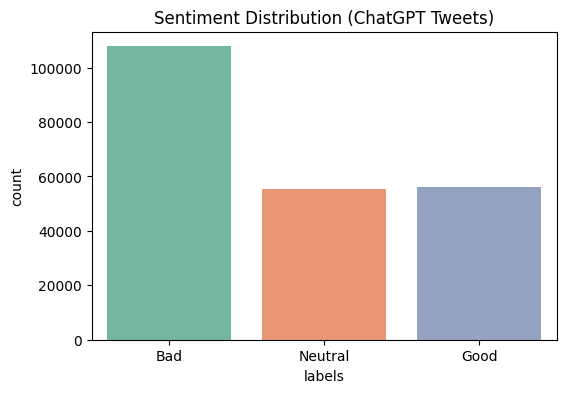

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["labels"], palette="Set2")
plt.xticks([0,1,2], ["Bad","Neutral","Good"])
plt.title("Sentiment Distribution (ChatGPT Tweets)")
plt.show()

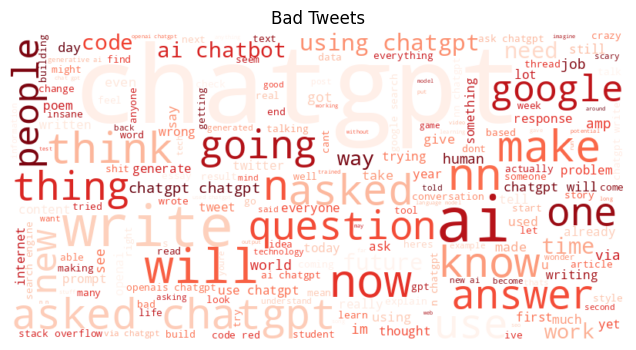

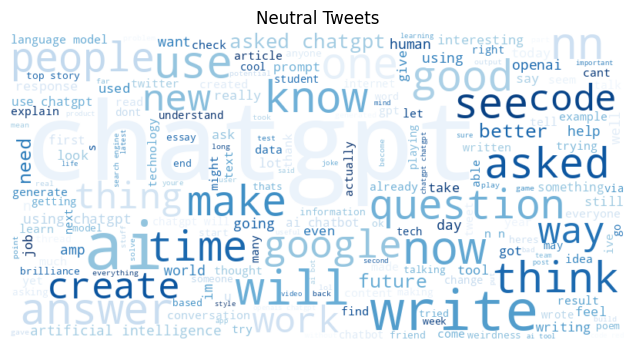

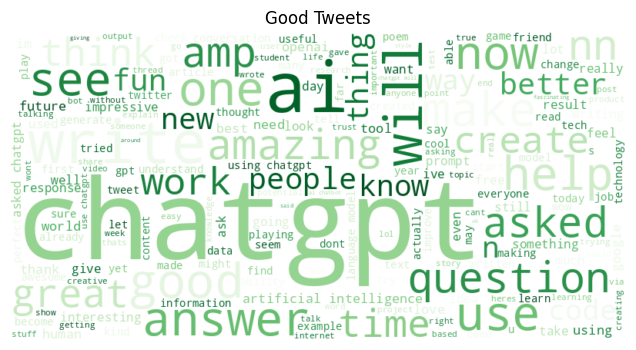

In [9]:
def plot_wordcloud(texts, title, cmap):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=cmap
    ).generate(" ".join(texts))

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(df[df.labels==0]["tweets"], "Bad Tweets", "Reds")
plot_wordcloud(df[df.labels==1]["tweets"], "Neutral Tweets", "Blues")
plot_wordcloud(df[df.labels==2]["tweets"], "Good Tweets", "Greens")

In [10]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["tweets"],
    df["labels"],
    test_size=0.3,
    stratify=df["labels"],
    random_state=42
)

In [ ]:
##########################################################################################################

In [11]:
# Create 50K subset with class balance
train_subset, _, label_subset, _ = train_test_split(
    train_texts,
    train_labels,
    train_size=50000,
    stratify=train_labels,
    random_state=42
)

print(len(train_subset), len(label_subset))

50000 50000


In [12]:
def objective(trial):

    # Better ngram tuning
    ngram_choice = trial.suggest_int("ngram", 1, 2)
    ngram_range = (1, ngram_choice)

    # Cleaner max_features
    max_features = trial.suggest_categorical(
        "max_features",
        [3000, 5000, 7000, 9000]
    )

    C = trial.suggest_float("C", 0.01, 100, log=True)
    k_neighbors = trial.suggest_int("k_neighbors", 3, 7)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=ngram_range,
            max_features=max_features,
            stop_words="english"
        )),
        ("smote", SMOTE(
            k_neighbors=k_neighbors,
            random_state=42
        )),
        ("clf", LogisticRegression(
            C=C,
            max_iter=1000,
            solver="liblinear"
        ))
    ])

    score = cross_val_score(
        pipeline,
        train_subset,
        label_subset,
        cv=3,                 # faster than 5
        scoring="f1_weighted",
        n_jobs=-1
    )

    return score.mean()

In [13]:
from imblearn.pipeline import Pipeline
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-08-14 05:30:03,575] A new study created in memory with name: no-name-1646f56d-9160-4e69-bd8d-5d561b5e9f44
[I 2026-08-14 05:30:23,200] Trial 0 finished with value: 0.7195704721501827 and parameters: {'ngram': 2, 'max_features': 3000, 'C': 23.18602411199931, 'k_neighbors': 5}. Best is trial 0 with value: 0.7195704721501827.
[I 2026-08-14 05:30:35,566] Trial 1 finished with value: 0.7184860570553608 and parameters: {'ngram': 1, 'max_features': 5000, 'C': 0.7807248387119398, 'k_neighbors': 7}. Best is trial 0 with value: 0.7195704721501827.
[I 2026-08-14 05:30:48,023] Trial 2 finished with value: 0.713871762208688 and parameters: {'ngram': 1, 'max_features': 3000, 'C': 0.4613271710265345, 'k_neighbors': 6}. Best is trial 0 with value: 0.7195704721501827.
[I 2026-08-14 05:31:04,207] Trial 3 finished with value: 0.7269283857748364 and parameters: {'ngram': 1, 'max_features': 5000, 'C': 1.4492042757417503, 'k_neighbors': 5}. Best is trial 3 with value: 0.7269283857748364.
[I 2026-08-1

Best Score: 0.7323816208815428
Best Params: {'ngram': 1, 'max_features': 5000, 'C': 5.055661909327469, 'k_neighbors': 3}


In [14]:
best_params = study.best_params

final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, best_params["ngram"]),
        max_features=best_params["max_features"],
        stop_words="english"
    )),
    ("smote", SMOTE(
        k_neighbors=best_params["k_neighbors"],
        random_state=42
    )),
    ("clf", LogisticRegression(
        C=best_params["C"],
        max_iter=1000,
        solver="liblinear"
    ))
])

# train on FULL data
final_model.fit(train_texts, train_labels)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('smote', SMOTE(k_neighbors=3, random_state=42)),
                ('clf',
                 LogisticRegression(C=5.055661909327469, max_iter=1000,
                                    solver='liblinear'))])

In [15]:
import os
os.makedirs("saved_models", exist_ok=True)
joblib.dump(final_model, "saved_models/logreg_sentiment_pipeline.joblib")
print("Saved: saved_models/logreg_sentiment_pipeline.joblib")


Saved: saved_models/logreg_sentiment_pipeline.joblib


In [16]:
val_preds = final_model.predict(val_texts)

print(classification_report(val_labels, val_preds))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     32339
           1       0.63      0.57      0.60     16646
           2       0.73      0.78      0.75     16804

    accuracy                           0.78     65789
   macro avg       0.75      0.75      0.75     65789
weighted avg       0.78      0.78      0.78     65789



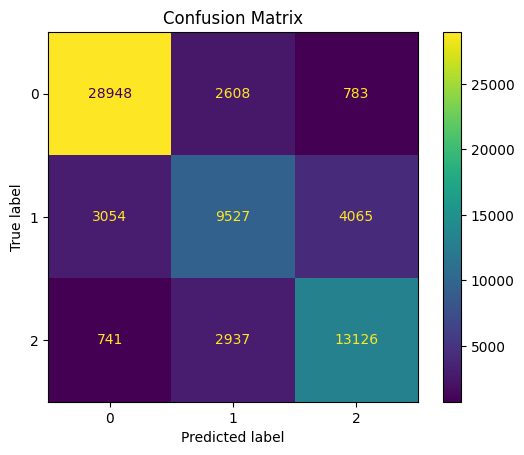

In [17]:
cm = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=final_model.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

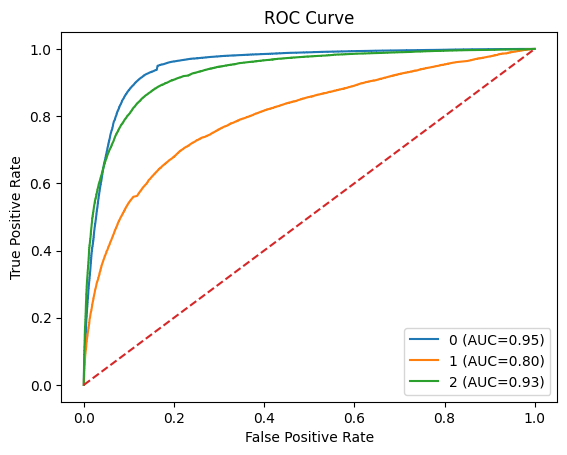

In [18]:
y_prob = final_model.predict_proba(val_texts)

classes = final_model.classes_
y_test_bin = label_binarize(val_labels, classes=classes)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

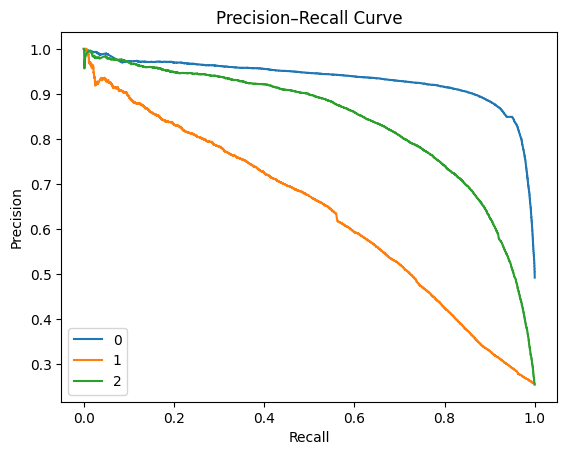

In [19]:
plt.figure()

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )
    plt.plot(recall, precision, label=classes[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

In [ ]:
#########################################################################################

In [20]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [21]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    output_attentions=True
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=96
        )
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [23]:
train_loader = DataLoader(
    SentimentDataset(train_texts, train_labels),
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    SentimentDataset(val_texts, val_labels),
    batch_size=16,
    pin_memory=True
)

In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
EPOCHS = 3

train_loss_history = []
val_loss_history = []

In [25]:
for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for batch in train_loader:
        optimizer.zero_grad()
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss_history.append(np.mean(train_losses))

    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k:v.to(device) for k,v in batch.items()}
            outputs = model(**batch)
            val_losses.append(outputs.loss.item())

    val_loss_history.append(np.mean(val_losses))

    print(f"Epoch {epoch+1} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

Epoch 1 | Train Loss: 0.3590 | Val Loss: 0.2217
Epoch 2 | Train Loss: 0.1988 | Val Loss: 0.1818
Epoch 3 | Train Loss: 0.1490 | Val Loss: 0.1816


In [ ]:
'''Epoch 1 → Train 0.3580 | Val 0.2256
Epoch 2 → Train 0.1968 | Val 0.1793
Epoch 3 → Train 0.1465 | Val 0.1781
Epoch 4 → Train 0.1527 | Val 0.1708
Epoch 5 → Train 0.1491 | Val 0.1715'''

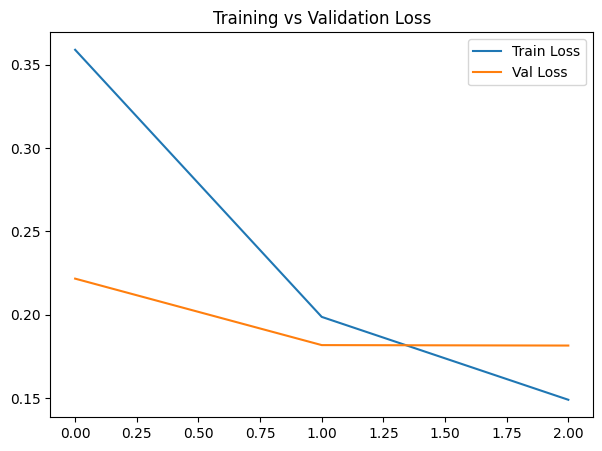

In [26]:
plt.figure(figsize=(7,5))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [27]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        inputs = {k:v.to(device) for k,v in batch.items() if k!="labels"}
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        y_true.extend(batch["labels"].numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=["Bad","Neutral","Good"]
))

              precision    recall  f1-score   support

         Bad       0.97      0.96      0.97     32339
     Neutral       0.89      0.88      0.89     16646
        Good       0.92      0.95      0.93     16804

    accuracy                           0.94     65789
   macro avg       0.93      0.93      0.93     65789
weighted avg       0.94      0.94      0.94     65789



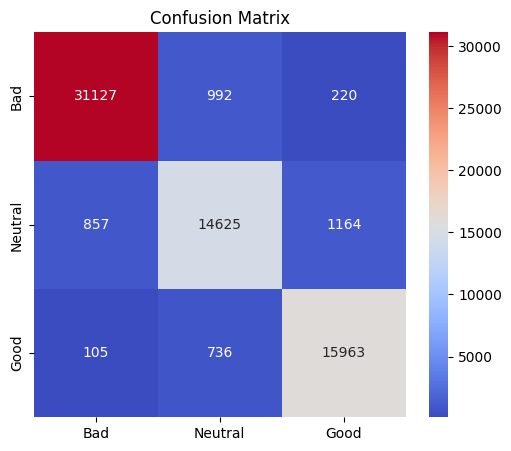

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=["Bad","Neutral","Good"],
    yticklabels=["Bad","Neutral","Good"]
)
plt.title("Confusion Matrix")
plt.show()

In [29]:
def plot_attention_heatmap(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attention = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="magma")
    plt.xticks(rotation=90)
    plt.title("Attention Heatmap")
    plt.show()

In [30]:
def predict_with_visual(text):
    text = clean_text(text)
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    labels = ["Bad","Neutral","Good"]

    plt.figure(figsize=(6,4))
    plt.bar(labels, probs, color="magenta")
    plt.ylim(0,1)
    plt.title("Sentiment Probability")
    plt.show()

    return labels[np.argmax(probs)], probs

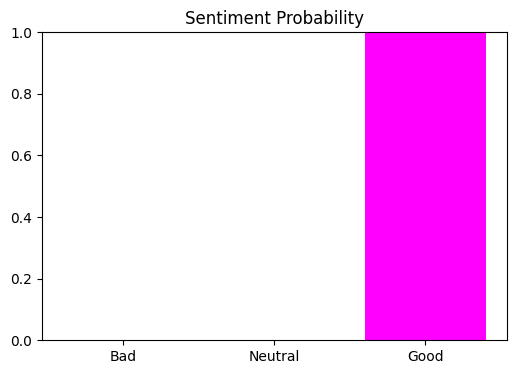

Sentiment: Good
Probabilities: [2.1568158e-04 2.0712633e-03 9.9771309e-01]


In [31]:
chat = "ChatGPT has significantly improved my productivity. It gives accurate answers,understands context very well, and helps me debug code faster than before."

text = clean_text(chat)
sentiment, probs = predict_with_visual(text)

print("Sentiment:", sentiment)
print("Probabilities:", probs)

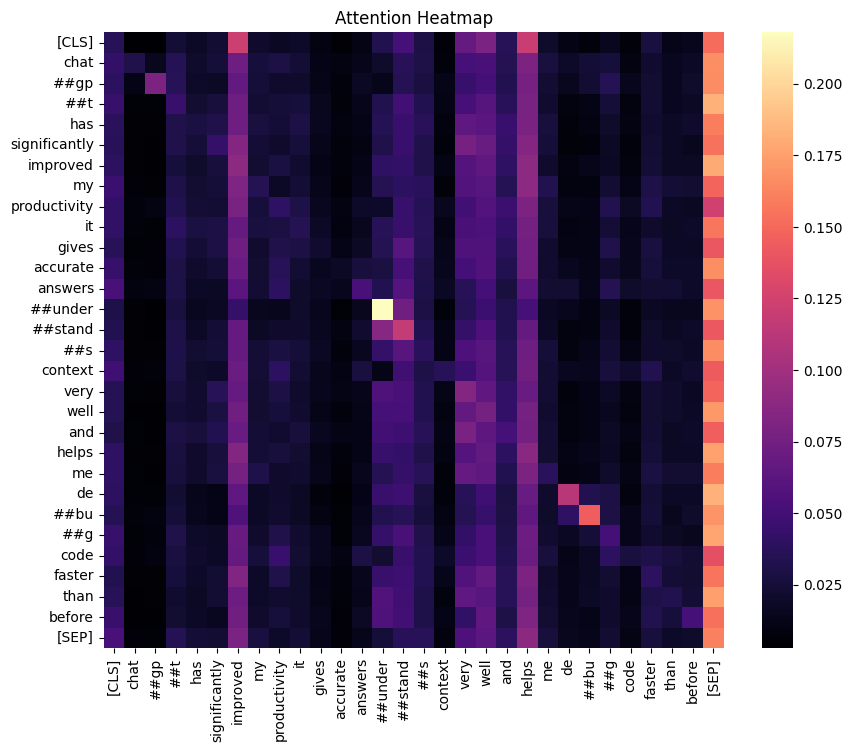

In [32]:
plot_attention_heatmap(text)

In [33]:
os.makedirs("saved_models/distilbert_sentiment", exist_ok=True)
model.save_pretrained("saved_models/distilbert_sentiment")
tokenizer.save_pretrained("saved_models/distilbert_sentiment")
print("Saved: saved_models/distilbert_sentiment/")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: saved_models/distilbert_sentiment/


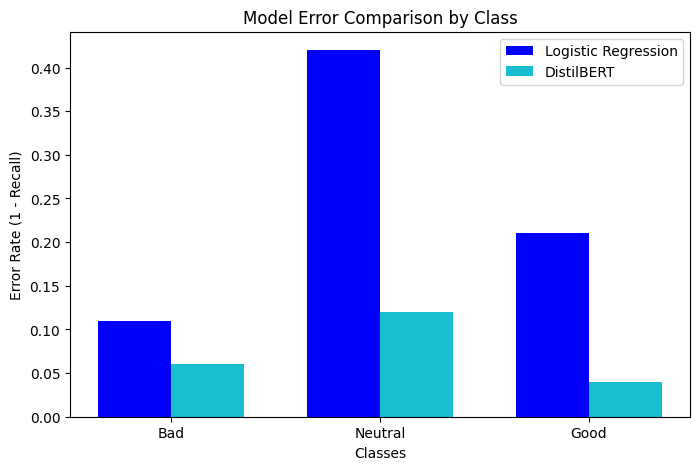

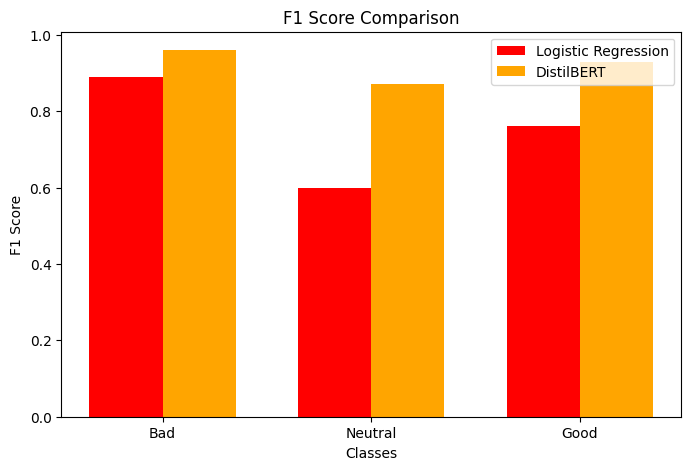

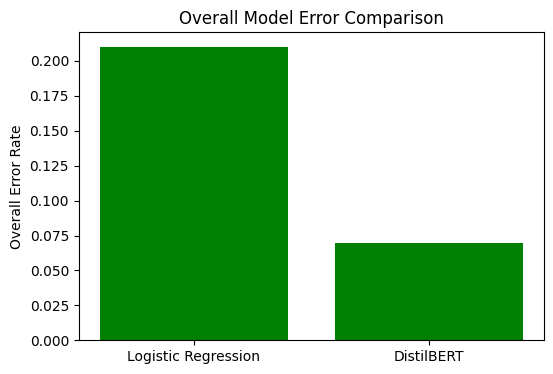

In [34]:

# -----------------------------
# 1. DEFINE METRICS (from your results)
# -----------------------------

classes = ["Bad", "Neutral", "Good"]

# Logistic Regression metrics
lr_precision = [0.89, 0.63, 0.73]
lr_recall = [0.89, 0.58, 0.79]
lr_f1 = [0.89, 0.60, 0.76]
lr_accuracy = 0.79

# DistilBERT metrics
bert_precision = [0.98, 0.87, 0.90]
bert_recall = [0.94, 0.88, 0.96]
bert_f1 = [0.96, 0.87, 0.93]
bert_accuracy = 0.93

# Convert recall → error rate
lr_error = [1 - x for x in lr_recall]
bert_error = [1 - x for x in bert_recall]

x = np.arange(len(classes))
width = 0.35


# -----------------------------
# 2. ERROR RATE COMPARISON
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_error, width, label="Logistic Regression", color="blue")
plt.bar(x + width/2, bert_error, width, label="DistilBERT", color="#17becf" )

plt.xlabel("Classes")
plt.ylabel("Error Rate (1 - Recall)")
plt.title("Model Error Comparison by Class")
plt.xticks(x, classes)
plt.legend()
plt.show()


# -----------------------------
# 3. F1 SCORE COMPARISON
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_f1, width, label="Logistic Regression", color="red")
plt.bar(x + width/2, bert_f1, width, label="DistilBERT", color="orange")

plt.xlabel("Classes")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.xticks(x, classes)
plt.legend()
plt.show()


# -----------------------------
# 4. OVERALL ERROR COMPARISON
# -----------------------------
models = ["Logistic Regression", "DistilBERT"]
overall_error = [1 - lr_accuracy, 1 - bert_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, overall_error, color="green")
plt.ylabel("Overall Error Rate")
plt.title("Overall Model Error Comparison")
plt.show()

In [ ]:
######### AB Testing #############

In [35]:
import random
import time
from scipy import stats

# FIX: seed the RNG so the A/B split is reproducible across runs
random.seed(42)


In [36]:
def ab_test_predict(text):

    model_choice = random.choice(["A", "B"])
    start = time.time()

    if model_choice == "A":
        # Logistic Regression (Pipeline model)
        probs = final_model.predict_proba([text])[0]
        pred = np.argmax(probs)
        model_used = "Logistic Regression"

    else:
        # DistilBERT
        inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs_tensor = torch.softmax(outputs.logits, dim=-1)

        probs = probs_tensor.cpu().numpy()[0]
        pred = np.argmax(probs)
        model_used = "DistilBERT"

    latency = time.time() - start

    return {
        "model": model_used,
        "prediction": int(pred),
        "latency": latency
    }


In [37]:
# FIX: val_texts/val_labels are pandas Series with a shuffled index left over
# from train_test_split. Plain slicing (val_texts[:200]) relies on pandas'
# slightly ambiguous label-vs-position behavior for slices - safer to be
# explicit and use .iloc, which is always positional.
#
# FIX: 200 rows total means ~100 per arm, which is too small to say anything
# about the weakest class (Neutral) with confidence - bumped this up to the
# full validation set so each arm gets a much larger sample.

N = len(val_texts)  # use full validation set instead of a fixed slice of 200
results = []

for text, true_label in zip(val_texts.iloc[:N], val_labels.iloc[:N]):
    result = ab_test_predict(text)
    result["true_label"] = int(true_label)
    result["correct"] = int(result["prediction"] == true_label)
    results.append(result)

ab_results = pd.DataFrame(results)
ab_results.head()


,model,prediction,latency,true_label,correct
0,Logistic Regression,0,0.001633,0,1
1,Logistic Regression,1,0.001106,0,0
2,DistilBERT,2,0.009177,2,1
3,Logistic Regression,0,0.001006,0,1
4,Logistic Regression,2,0.000905,2,1


In [38]:
# FIX #1: the original cell had two un-printed expressions - in Jupyter only
# the LAST expression in a cell auto-displays, so the accuracy comparison
# was silently dropped and only latency ever showed. Both are now printed
# explicitly.

acc_by_model = ab_results.groupby("model")["correct"].mean()
lat_by_model = ab_results.groupby("model")["latency"].mean()
n_by_model = ab_results.groupby("model")["correct"].count()

print("Sample size per model:")
print(n_by_model)
print()
print("Accuracy comparison:")
print(acc_by_model)
print()
print("Latency comparison (seconds):")
print(lat_by_model)

# FIX #2: no significance test existed at all - a difference in means on a
# small sample can easily be noise. Add a minimum-sample-size guard plus a
# real hypothesis test before claiming either model is "better".

MIN_SAMPLES = 30

lr = ab_results[ab_results["model"] == "Logistic Regression"]
bert = ab_results[ab_results["model"] == "DistilBERT"]

print("\n--- Significance testing ---")

if len(lr) < MIN_SAMPLES or len(bert) < MIN_SAMPLES:
    print(f"Need at least {MIN_SAMPLES} samples per model to test reliably "
          f"(LR={len(lr)}, DistilBERT={len(bert)}). Re-run with a larger N.")
else:
    # Two-proportion z-test on accuracy
    n_a, n_b = len(lr), len(bert)
    p_a, p_b = lr["correct"].mean(), bert["correct"].mean()
    p_pool = (lr["correct"].sum() + bert["correct"].sum()) / (n_a + n_b)
    se = (p_pool * (1 - p_pool) * (1/n_a + 1/n_b)) ** 0.5
    z = (p_a - p_b) / se if se > 0 else 0
    p_value_acc = 2 * (1 - stats.norm.cdf(abs(z)))

    acc_verdict = "SIGNIFICANT (p<0.05)" if p_value_acc < 0.05 else "not significant"
    print(f"Accuracy - LR: {p_a:.4f} | DistilBERT: {p_b:.4f}")
    print(f"Two-proportion z-test: z={z:.4f}, p={p_value_acc:.4f} -> {acc_verdict}")

    # Welch's t-test on latency (unequal variances assumed)
    lr_lat_mean = lr["latency"].mean()
    bert_lat_mean = bert["latency"].mean()
    t_stat, p_value_lat = stats.ttest_ind(
        lr["latency"], bert["latency"], equal_var=False
    )
    lat_verdict = "SIGNIFICANT (p<0.05)" if p_value_lat < 0.05 else "not significant"
    print(f"\nLatency - LR: {lr_lat_mean:.4f}s | DistilBERT: {bert_lat_mean:.4f}s")
    print(f"Welch's t-test: t={t_stat:.4f}, p={p_value_lat:.4f} -> {lat_verdict}")


    # FIX #3: Welch's t-test assumes roughly-normal latency distributions,
    # but inference latencies are usually right-skewed (GPU/CPU warm-up,
    # occasional slow calls). Add a Mann-Whitney U test as a distribution-free
    # cross-check on the same latency data.
    u_stat, p_value_lat_mw = stats.mannwhitneyu(
        lr["latency"], bert["latency"], alternative="two-sided"
    )
    lat_verdict_mw = "SIGNIFICANT (p<0.05)" if p_value_lat_mw < 0.05 else "not significant"
    print(f"Mann-Whitney U (distribution-free check): U={u_stat:.4f}, p={p_value_lat_mw:.4f} -> {lat_verdict_mw}")


Sample size per model:
model
DistilBERT             32978
Logistic Regression    32811
Name: correct, dtype: int64

Accuracy comparison:
model
DistilBERT             0.937686
Logistic Regression    0.785621
Name: correct, dtype: float64

Latency comparison (seconds):
model
DistilBERT             0.006011
Logistic Regression    0.000940
Name: latency, dtype: float64

--- Significance testing ---
Accuracy - LR: 0.7856 | DistilBERT: 0.9377
Two-proportion z-test: z=-56.5169, p=0.0000 -> SIGNIFICANT (p<0.05)

Latency - LR: 0.0009s | DistilBERT: 0.0060s
Welch's t-test: t=-740.0969, p=0.0000 -> SIGNIFICANT (p<0.05)
Mann-Whitney U (distribution-free check): U=0.0000, p=0.0000 -> SIGNIFICANT (p<0.05)
